# Wind Power Forecast Error Analysis

Analysis of UK wind generation forecast accuracy using Elexon BMRS data (Jan 2025 onwards).  
This notebook structures the data pipeline and visualisations. Interpretation cells are left blank for analyst input.

In [1]:
# ============================================================
# SETUP — Libraries, Constants, Data Fetching
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
from datetime import datetime, timedelta, timezone
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Constants ────────────────────────────────────────────────
FUELHH_URL = 'https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream'
WINDFOR_URL = 'https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream'

DATA_START = '2025-01-01T00:00:00Z'
DATA_END = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')

FUEL_TYPE_FILTER = 'WIND'
MAX_HORIZON_HOURS = 48

FIGURE_DIR = 'figures'
FIGURE_SIZE = (12, 5)
HIST_BINS = 50

# Horizon bucket edges (in hours)
HORIZON_BINS = [0, 6, 12, 18, 24, 36, 48]
HORIZON_LABELS = ['0-6h', '6-12h', '12-18h', '18-24h', '24-36h', '36-48h']

os.makedirs(FIGURE_DIR, exist_ok=True)
print(f'Date range: {DATA_START} → {DATA_END}')

Date range: 2025-01-01T00:00:00Z → 2026-03-19T07:51:01Z


In [2]:
# ── Helper: fetch data in monthly chunks to avoid API limits ──

def fetch_chunks(url: str, start: str, end: str, chunk_days: int = 7) -> list:
    """Fetch data from Elexon API in time-windowed chunks."""
    all_data = []
    current = pd.Timestamp(start, tz='UTC')
    end_ts = pd.Timestamp(end, tz='UTC')
    
    while current < end_ts:
        chunk_end = min(current + pd.Timedelta(days=chunk_days), end_ts)
        params = {
            'publishDateTimeFrom': current.isoformat(),
            'publishDateTimeTo': chunk_end.isoformat(),
        }
        resp = requests.get(url, params=params, headers={'Accept': 'application/json'}, timeout=60)
        resp.raise_for_status()
        data = resp.json()
        all_data.extend(data)
        print(f'  Fetched {len(data):,} records for {current.date()} → {chunk_end.date()}')
        current = chunk_end
    
    return all_data

print('Helper defined.')

Helper defined.


In [3]:
# ── Fetch actuals (FUELHH, WIND only) ────────────────────────

print('Fetching FUELHH (actuals)...')
raw_actuals = fetch_chunks(FUELHH_URL, DATA_START, DATA_END)

df_actuals_raw = pd.DataFrame(raw_actuals)
print(f'Total raw FUELHH records: {len(df_actuals_raw):,}')

# Filter to WIND fuel type only
df_actuals = df_actuals_raw[df_actuals_raw['fuelType'] == FUEL_TYPE_FILTER].copy()
df_actuals['startTime'] = pd.to_datetime(df_actuals['startTime'], utc=True)
df_actuals['publishTime'] = pd.to_datetime(df_actuals['publishTime'], utc=True)

# Deduplicate: keep latest publishTime per startTime
df_actuals = (
    df_actuals
    .sort_values('publishTime')
    .drop_duplicates(subset='startTime', keep='last')
    .rename(columns={'generation': 'actual'})
    [['startTime', 'actual']]
    .sort_values('startTime')
    .reset_index(drop=True)
)

print(f'Wind actuals: {len(df_actuals):,} half-hour periods')
print(f'Range: {df_actuals["startTime"].min()} → {df_actuals["startTime"].max()}')
df_actuals.head()

Fetching FUELHH (actuals)...
  Fetched 6,740 records for 2025-01-01 → 2025-01-08
  Fetched 6,740 records for 2025-01-08 → 2025-01-15
  Fetched 6,740 records for 2025-01-15 → 2025-01-22
  Fetched 6,740 records for 2025-01-22 → 2025-01-29
  Fetched 6,740 records for 2025-01-29 → 2025-02-05
  Fetched 6,740 records for 2025-02-05 → 2025-02-12
  Fetched 6,740 records for 2025-02-12 → 2025-02-19
  Fetched 6,740 records for 2025-02-19 → 2025-02-26
  Fetched 6,740 records for 2025-02-26 → 2025-03-05
  Fetched 6,740 records for 2025-03-05 → 2025-03-12
  Fetched 6,740 records for 2025-03-12 → 2025-03-19
  Fetched 6,740 records for 2025-03-19 → 2025-03-26
  Fetched 6,740 records for 2025-03-26 → 2025-04-02
  Fetched 6,740 records for 2025-04-02 → 2025-04-09
  Fetched 6,740 records for 2025-04-09 → 2025-04-16
  Fetched 6,740 records for 2025-04-16 → 2025-04-23
  Fetched 6,740 records for 2025-04-23 → 2025-04-30
  Fetched 6,740 records for 2025-04-30 → 2025-05-07
  Fetched 6,740 records for 2025-05

,startTime,actual
0,2024-12-31 23:30:00+00:00,15522
1,2025-01-01 00:00:00+00:00,15799
2,2025-01-01 00:30:00+00:00,15317
3,2025-01-01 01:00:00+00:00,14992
4,2025-01-01 01:30:00+00:00,14580


In [4]:
# ── Fetch forecasts (WINDFOR) ────────────────────────────────

print('Fetching WINDFOR (forecasts)...')
raw_forecasts = fetch_chunks(WINDFOR_URL, DATA_START, DATA_END)

df_forecasts_raw = pd.DataFrame(raw_forecasts)
print(f'Total raw WINDFOR records: {len(df_forecasts_raw):,}')

df_forecasts = df_forecasts_raw.copy()
df_forecasts['startTime'] = pd.to_datetime(df_forecasts['startTime'], utc=True)
df_forecasts['publishTime'] = pd.to_datetime(df_forecasts['publishTime'], utc=True)

# Compute forecast horizon in hours
df_forecasts['forecast_horizon_hours'] = (
    (df_forecasts['startTime'] - df_forecasts['publishTime']).dt.total_seconds() / 3600
)

# Filter: horizon between 0 and MAX_HORIZON_HOURS
df_forecasts = df_forecasts[
    (df_forecasts['forecast_horizon_hours'] >= 0) &
    (df_forecasts['forecast_horizon_hours'] <= MAX_HORIZON_HOURS)
].copy()

# For each startTime, keep the LATEST publishTime (most recent forecast)
df_forecasts = (
    df_forecasts
    .sort_values('publishTime')
    .drop_duplicates(subset='startTime', keep='last')
    .rename(columns={'generation': 'forecast'})
    [['startTime', 'publishTime', 'forecast', 'forecast_horizon_hours']]
    .sort_values('startTime')
    .reset_index(drop=True)
)

print(f'Wind forecasts (deduplicated): {len(df_forecasts):,} periods')
print(f'Range: {df_forecasts["startTime"].min()} → {df_forecasts["startTime"].max()}')
df_forecasts.head()

Fetching WINDFOR (forecasts)...
  Fetched 4,088 records for 2025-01-01 → 2025-01-08
  Fetched 4,088 records for 2025-01-08 → 2025-01-15
  Fetched 4,088 records for 2025-01-15 → 2025-01-22
  Fetched 4,088 records for 2025-01-22 → 2025-01-29
  Fetched 4,088 records for 2025-01-29 → 2025-02-05
  Fetched 4,088 records for 2025-02-05 → 2025-02-12
  Fetched 4,088 records for 2025-02-12 → 2025-02-19
  Fetched 4,088 records for 2025-02-19 → 2025-02-26
  Fetched 4,088 records for 2025-02-26 → 2025-03-05
  Fetched 4,088 records for 2025-03-05 → 2025-03-12
  Fetched 4,088 records for 2025-03-12 → 2025-03-19
  Fetched 4,088 records for 2025-03-19 → 2025-03-26
  Fetched 4,064 records for 2025-03-26 → 2025-04-02
  Fetched 4,088 records for 2025-04-02 → 2025-04-09
  Fetched 4,088 records for 2025-04-09 → 2025-04-16
  Fetched 4,088 records for 2025-04-16 → 2025-04-23
  Fetched 4,088 records for 2025-04-23 → 2025-04-30
  Fetched 4,088 records for 2025-04-30 → 2025-05-07
  Fetched 4,088 records for 2025

,startTime,publishTime,forecast,forecast_horizon_hours
0,2025-01-01 03:00:00+00:00,2025-01-01 02:30:00+00:00,18070,0.5
1,2025-01-01 04:00:00+00:00,2025-01-01 02:30:00+00:00,18146,1.5
2,2025-01-01 05:00:00+00:00,2025-01-01 04:30:00+00:00,18054,0.5
3,2025-01-01 06:00:00+00:00,2025-01-01 04:30:00+00:00,17417,1.5
4,2025-01-01 07:00:00+00:00,2025-01-01 04:30:00+00:00,17536,2.5


In [5]:
# ── Merge actuals + forecasts (inner join on startTime) ──────

df = pd.merge(df_actuals, df_forecasts, on='startTime', how='inner')

# Compute error metrics
df['error'] = df['forecast'] - df['actual']           # signed error
df['abs_error'] = df['error'].abs()                    # absolute error

print(f'Merged dataset: {len(df):,} matched periods')
print(f'\nDate range: {df["startTime"].min()} → {df["startTime"].max()}')
print(f'Mean actual: {df["actual"].mean():,.0f} MW')
print(f'Mean forecast: {df["forecast"].mean():,.0f} MW')
print(f'Mean error: {df["error"].mean():+,.0f} MW')
df.head()

Merged dataset: 10,613 matched periods

Date range: 2025-01-01 03:00:00+00:00 → 2026-03-19 07:00:00+00:00
Mean actual: 8,407 MW
Mean forecast: 9,650 MW
Mean error: +1,244 MW


,startTime,actual,publishTime,forecast,forecast_horizon_hours,error,abs_error
0,2025-01-01 03:00:00+00:00,14831,2025-01-01 02:30:00+00:00,18070,0.5,3239,3239
1,2025-01-01 04:00:00+00:00,15078,2025-01-01 02:30:00+00:00,18146,1.5,3068,3068
2,2025-01-01 05:00:00+00:00,14732,2025-01-01 04:30:00+00:00,18054,0.5,3322,3322
3,2025-01-01 06:00:00+00:00,15220,2025-01-01 04:30:00+00:00,17417,1.5,2197,2197
4,2025-01-01 07:00:00+00:00,14793,2025-01-01 04:30:00+00:00,17536,2.5,2743,2743


---
## Section 1 — Overall Error Distribution

In [6]:
# ── 1a: Summary statistics table ─────────────────────────────

mae = df['abs_error'].mean()
median_ae = df['abs_error'].median()
p90_ae = df['abs_error'].quantile(0.90)
p95_ae = df['abs_error'].quantile(0.95)
p99_ae = df['abs_error'].quantile(0.99)
rmse = np.sqrt((df['error'] ** 2).mean())
mean_bias = df['error'].mean()

# Symmetric MAPE: 200 * |forecast - actual| / (|forecast| + |actual|)
smape = (200 * df['abs_error'] / (df['forecast'].abs() + df['actual'].abs())).mean()

summary = pd.DataFrame({
    'Metric': ['MAE', 'Median AE', 'P90 AE', 'P95 AE', 'P99 AE', 
               'RMSE', 'Mean Bias', 'sMAPE (%)'],
    'Value': [f'{mae:,.0f} MW', f'{median_ae:,.0f} MW', f'{p90_ae:,.0f} MW',
              f'{p95_ae:,.0f} MW', f'{p99_ae:,.0f} MW', f'{rmse:,.0f} MW',
              f'{mean_bias:+,.0f} MW', f'{smape:.1f}%']
})

print('\n=== Overall Forecast Error Summary ===')
print(summary.to_string(index=False))


=== Overall Forecast Error Summary ===
   Metric     Value
      MAE  1,459 MW
Median AE  1,014 MW
   P90 AE  3,435 MW
   P95 AE  4,224 MW
   P99 AE  5,862 MW
     RMSE  1,989 MW
Mean Bias +1,244 MW
sMAPE (%)     17.5%


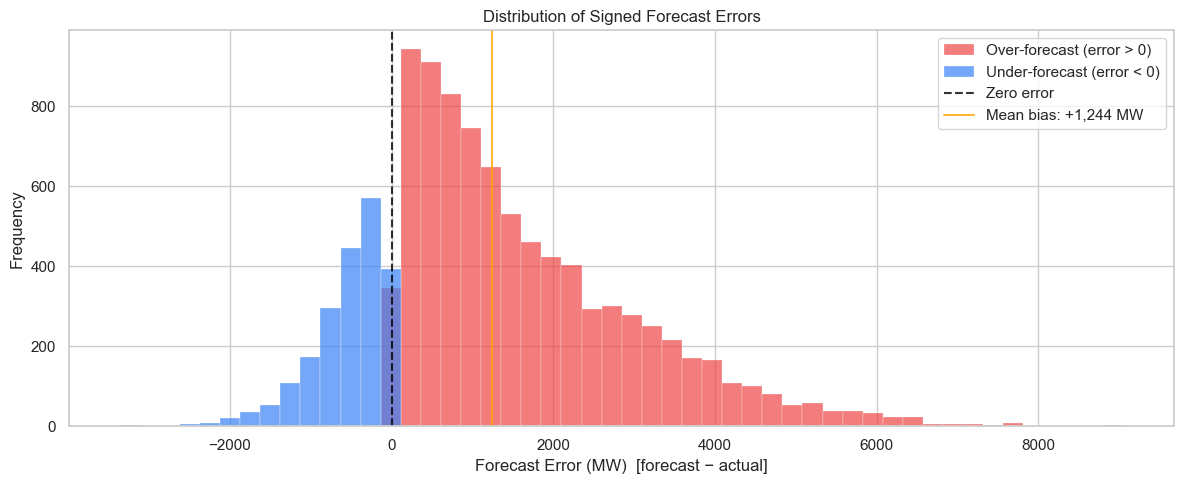

In [7]:
# ── 1b: Histogram of signed errors ───────────────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

# Split into positive (over-forecast) and negative (under-forecast)
errors = df['error']
bins = np.linspace(errors.min(), errors.max(), HIST_BINS + 1)

ax.hist(errors[errors >= 0], bins=bins, color='#ef4444', alpha=0.7, 
        label='Over-forecast (error > 0)', edgecolor='white', linewidth=0.3)
ax.hist(errors[errors < 0], bins=bins, color='#3b82f6', alpha=0.7, 
        label='Under-forecast (error < 0)', edgecolor='white', linewidth=0.3)

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.8, label='Zero error')
ax.axvline(mean_bias, color='orange', linewidth=1.5, linestyle='-', alpha=0.8,
           label=f'Mean bias: {mean_bias:+,.0f} MW')

ax.set_xlabel('Forecast Error (MW)  [forecast − actual]')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Signed Forecast Errors')
ax.legend(loc='upper right')
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/01_signed_error_histogram.png', dpi=150)
plt.show()

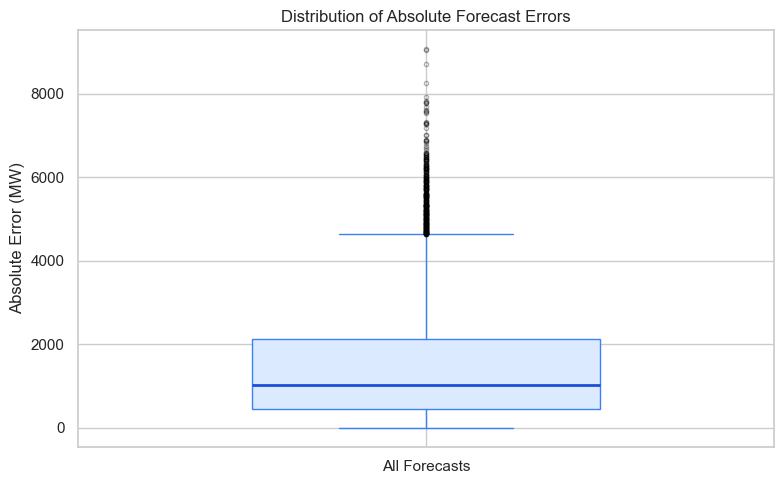

In [8]:
# ── 1c: Box plot of absolute errors ──────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot(df['abs_error'], vert=True, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor='#dbeafe', edgecolor='#3b82f6'),
                medianprops=dict(color='#1d4ed8', linewidth=2),
                whiskerprops=dict(color='#3b82f6'),
                capprops=dict(color='#3b82f6'),
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='#3b82f6'))

ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Distribution of Absolute Forecast Errors')
ax.set_xticklabels(['All Forecasts'])
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/02_abs_error_boxplot.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of the overall error distribution here]_

---
## Section 2 — Error vs Forecast Horizon

In [9]:
# ── 2a: Bucket forecast horizons and compute stats ───────────

df['horizon_bucket'] = pd.cut(
    df['forecast_horizon_hours'],
    bins=HORIZON_BINS,
    labels=HORIZON_LABELS,
    right=False
)

horizon_stats = df.groupby('horizon_bucket', observed=True).agg(
    count=('abs_error', 'size'),
    MAE=('abs_error', 'mean'),
    Median_AE=('abs_error', 'median'),
    Std_AE=('abs_error', 'std'),
    RMSE=('error', lambda x: np.sqrt((x ** 2).mean())),
    Bias=('error', 'mean'),
).round(0)

print('=== Error Metrics by Forecast Horizon ===')
print(horizon_stats.to_string())

=== Error Metrics by Forecast Horizon ===
                count     MAE  Median_AE  Std_AE    RMSE    Bias
horizon_bucket                                                  
0-6h            10613  1459.0     1014.0  1352.0  1989.0  1244.0


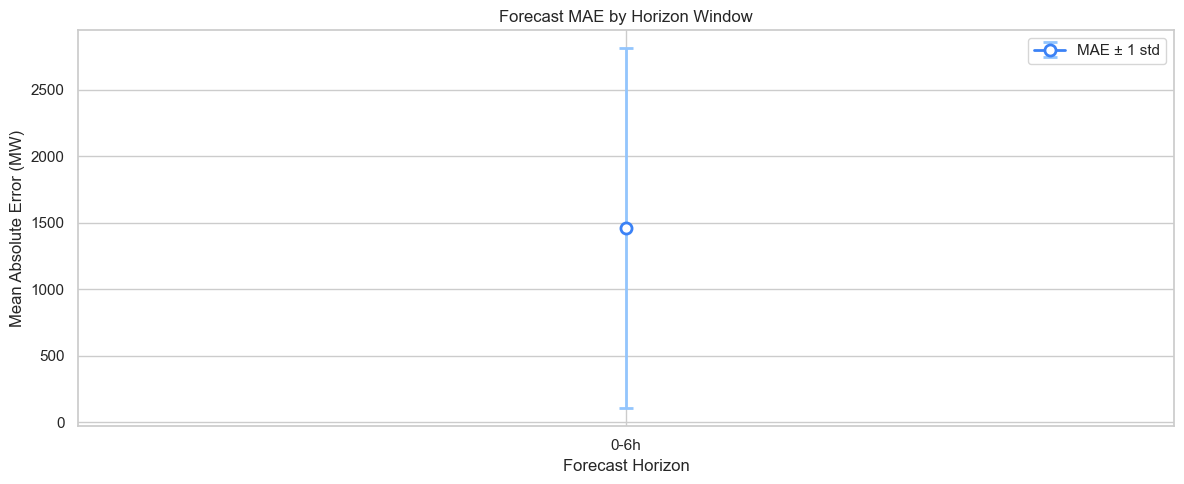

In [10]:
# ── 2b: Line chart — MAE vs horizon bucket ──────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = range(len(horizon_stats))
ax.errorbar(x, horizon_stats['MAE'], yerr=horizon_stats['Std_AE'],
            marker='o', linewidth=2, color='#3b82f6', capsize=5,
            capthick=1.5, ecolor='#93c5fd', markerfacecolor='white',
            markeredgecolor='#3b82f6', markeredgewidth=2, markersize=8,
            label='MAE ± 1 std')

ax.set_xticks(x)
ax.set_xticklabels(horizon_stats.index)
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Mean Absolute Error (MW)')
ax.set_title('Forecast MAE by Horizon Window')
ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/03_mae_vs_horizon.png', dpi=150)
plt.show()

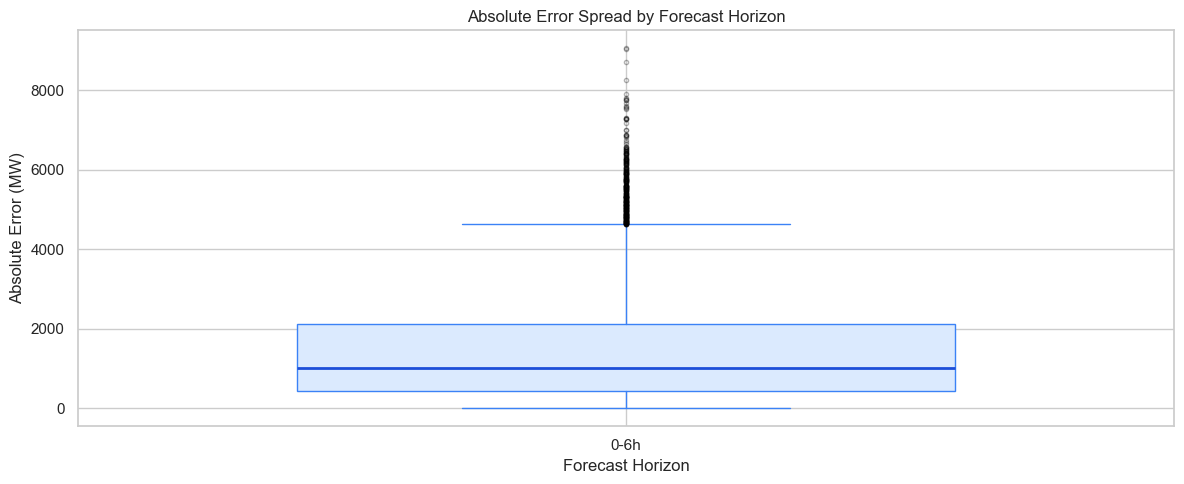

In [11]:
# ── 2c: Box plots — abs error spread per horizon bucket ──────

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

# Prepare data for each bucket
box_data = [group['abs_error'].values for _, group in df.groupby('horizon_bucket', observed=True)]
box_labels = [str(label) for label in horizon_stats.index]

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6,
                boxprops=dict(facecolor='#dbeafe', edgecolor='#3b82f6'),
                medianprops=dict(color='#1d4ed8', linewidth=2),
                whiskerprops=dict(color='#3b82f6'),
                capprops=dict(color='#3b82f6'),
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='#3b82f6'))

ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title('Absolute Error Spread by Forecast Horizon')
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/04_horizon_boxplots.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of how error varies with forecast horizon]_

---
## Section 3 — Error by Time of Day

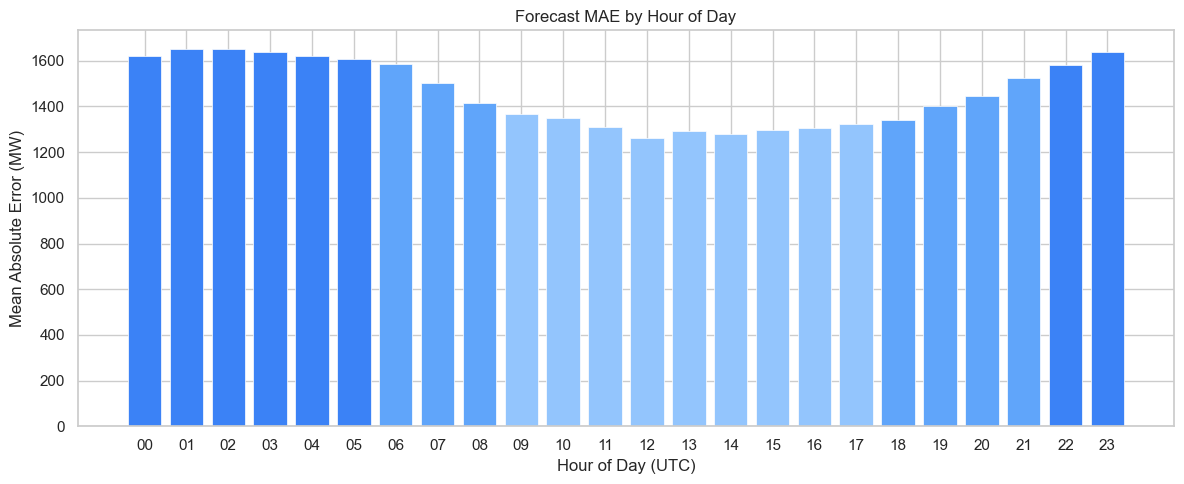

In [12]:
# ── 3a: MAE by hour of day ───────────────────────────────────

df['hour_of_day'] = df['startTime'].dt.hour

hourly_mae = df.groupby('hour_of_day')['abs_error'].mean()
hourly_bias = df.groupby('hour_of_day')['error'].mean()

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

colors = ['#3b82f6' if h < 6 or h >= 22 else '#60a5fa' if h < 9 or h >= 18 else '#93c5fd' 
          for h in range(24)]
ax.bar(hourly_mae.index, hourly_mae.values, color=colors, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Mean Absolute Error (MW)')
ax.set_title('Forecast MAE by Hour of Day')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/05_mae_by_hour.png', dpi=150)
plt.show()

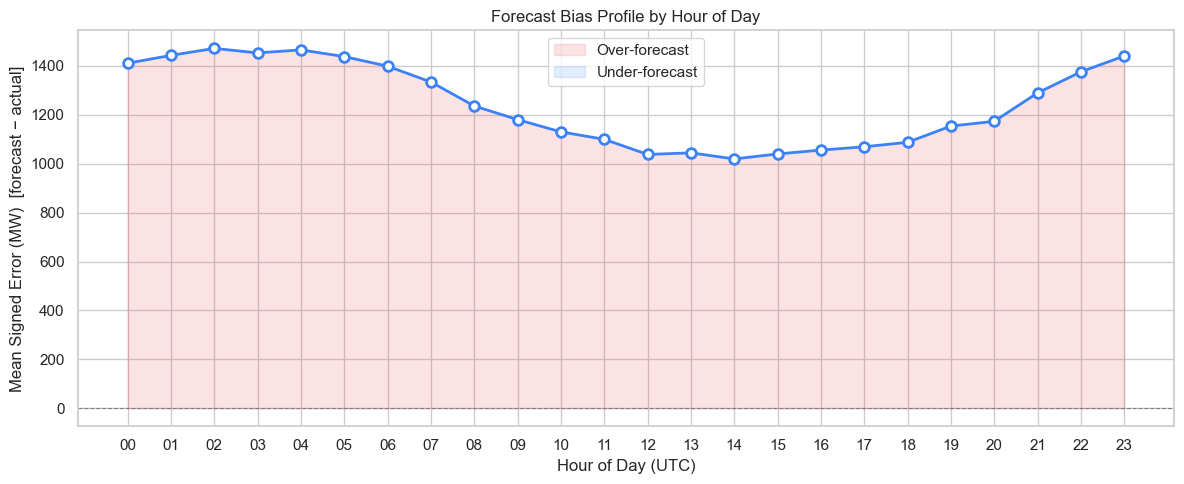

In [13]:
# ── 3b: Signed bias profile by hour ──────────────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

ax.plot(hourly_bias.index, hourly_bias.values, marker='o', linewidth=2,
        color='#3b82f6', markerfacecolor='white', markeredgecolor='#3b82f6',
        markeredgewidth=2, markersize=7)
ax.fill_between(hourly_bias.index, 0, hourly_bias.values,
                where=hourly_bias.values >= 0, alpha=0.15, color='#ef4444',
                label='Over-forecast')
ax.fill_between(hourly_bias.index, 0, hourly_bias.values,
                where=hourly_bias.values < 0, alpha=0.15, color='#3b82f6',
                label='Under-forecast')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Mean Signed Error (MW)  [forecast − actual]')
ax.set_title('Forecast Bias Profile by Hour of Day')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/06_bias_by_hour.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of time-of-day error patterns]_

---
## Section 4 — Error by Day of Week

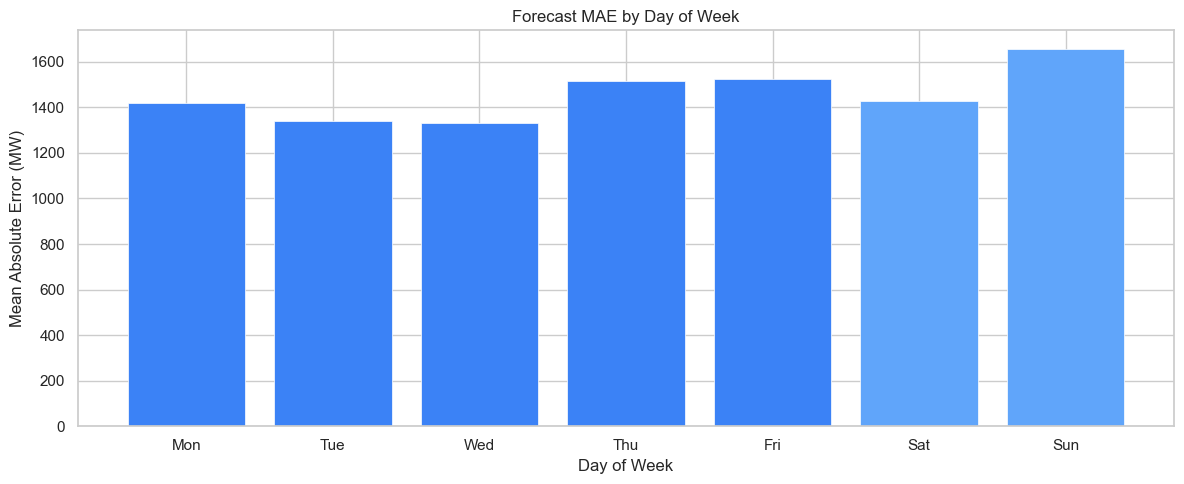

In [14]:
# ── 4a: MAE by weekday ───────────────────────────────────────

df['weekday'] = df['startTime'].dt.dayofweek  # Mon=0 ... Sun=6
weekday_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

weekday_mae = df.groupby('weekday')['abs_error'].mean()

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

colors = ['#3b82f6'] * 5 + ['#60a5fa'] * 2  # Slightly lighter for weekends
ax.bar(weekday_mae.index, weekday_mae.values, color=colors, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Day of Week')
ax.set_ylabel('Mean Absolute Error (MW)')
ax.set_title('Forecast MAE by Day of Week')
ax.set_xticks(range(7))
ax.set_xticklabels(weekday_names)
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/07_mae_by_weekday.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of day-of-week patterns]_

---
## Section 5 — Error Over Time (Drift Analysis)

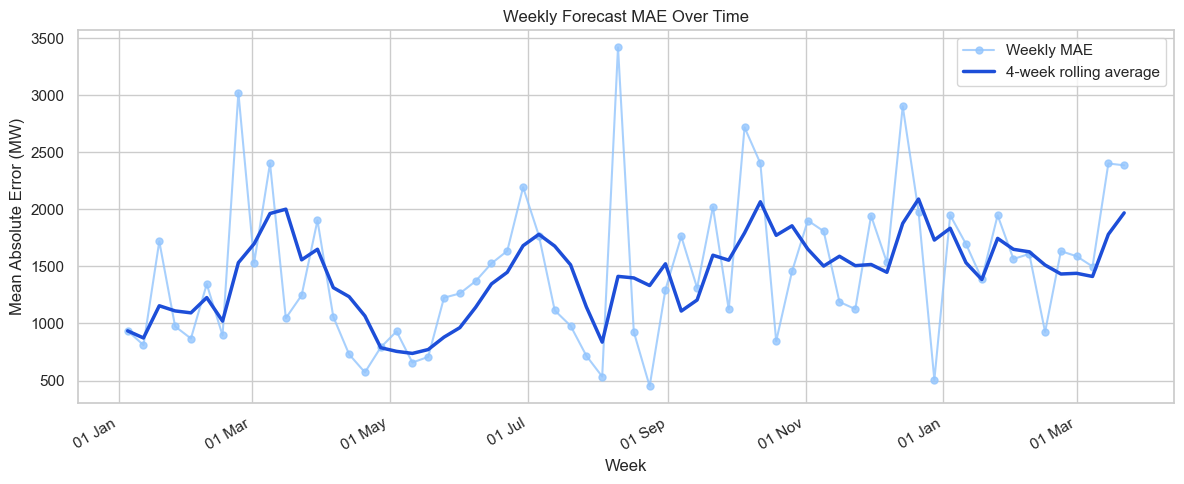

In [15]:
# ── 5a: Weekly MAE over time ─────────────────────────────────

df_ts = df.set_index('startTime')
weekly_mae = df_ts['abs_error'].resample('W').mean()
rolling_4w = weekly_mae.rolling(4, min_periods=1).mean()

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

ax.plot(weekly_mae.index, weekly_mae.values, marker='o', linewidth=1.5,
        color='#93c5fd', markersize=5, alpha=0.8, label='Weekly MAE')
ax.plot(rolling_4w.index, rolling_4w.values, linewidth=2.5,
        color='#1d4ed8', label='4-week rolling average')

ax.set_xlabel('Week')
ax.set_ylabel('Mean Absolute Error (MW)')
ax.set_title('Weekly Forecast MAE Over Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/08_weekly_mae_drift.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of forecast performance drift / trends]_

---
## Section 6 — Worst Performing Periods

In [16]:
# ── 6a: Top 20 highest absolute errors ───────────────────────

TOP_N = 20

worst = (
    df.nlargest(TOP_N, 'abs_error')
    [['startTime', 'actual', 'forecast', 'error', 'abs_error', 'forecast_horizon_hours']]
    .reset_index(drop=True)
)

# Format for display
worst_display = worst.copy()
worst_display['startTime'] = worst_display['startTime'].dt.strftime('%Y-%m-%d %H:%M UTC')
worst_display = worst_display.rename(columns={
    'startTime': 'Time',
    'actual': 'Actual (MW)',
    'forecast': 'Forecast (MW)',
    'error': 'Error (MW)',
    'abs_error': '|Error| (MW)',
    'forecast_horizon_hours': 'Horizon (h)',
})

print(f'=== Top {TOP_N} Worst Forecast Errors ===')
print(worst_display.to_string(index=False))

=== Top 20 Worst Forecast Errors ===
                Time  Actual (MW)  Forecast (MW)  Error (MW)  |Error| (MW)  Horizon (h)
2025-03-11 11:00 UTC            0           9059        9059          9059          1.5
2026-02-24 11:00 UTC         5801          14839        9038          9038          1.5
2025-08-05 14:00 UTC         9282          17992        8710          8710          1.5
2025-05-25 08:00 UTC        11019          19274        8255          8255          2.5
2025-05-25 07:00 UTC        11180          19093        7913          7913          1.5
2025-09-07 08:00 UTC        11794          19606        7812          7812          2.5
2025-08-05 13:00 UTC        10702          18495        7793          7793          0.5
2025-08-05 12:00 UTC        10861          18629        7768          7768          3.5
2025-05-25 09:00 UTC        11468          19232        7764          7764          0.5
2025-05-25 06:00 UTC        11072          18752        7680          7680         

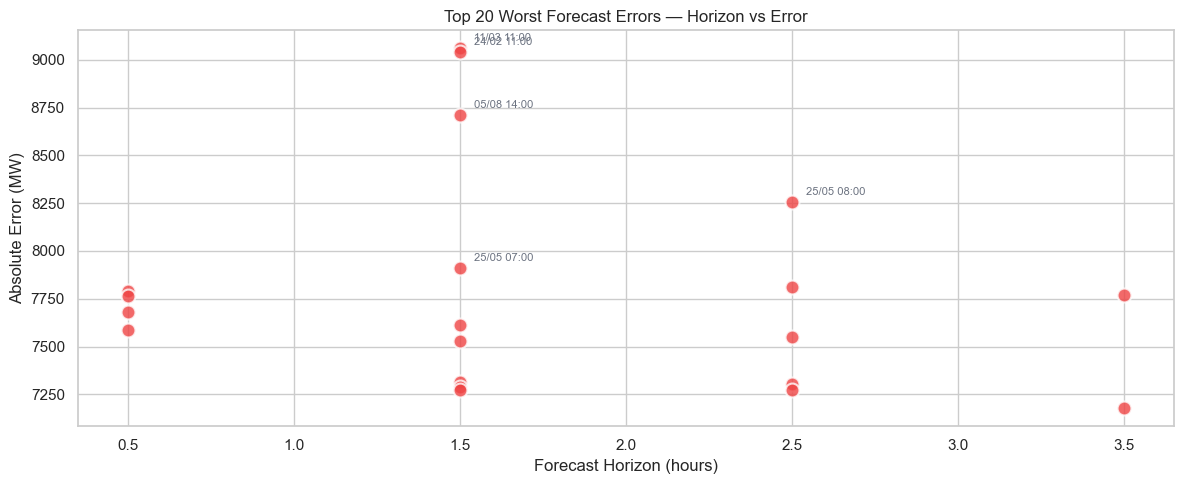

In [17]:
# ── 6b: Scatter — horizon vs absolute error for worst periods ─

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

ax.scatter(worst['forecast_horizon_hours'], worst['abs_error'],
           s=100, c='#ef4444', edgecolors='white', linewidth=1.5,
           alpha=0.8, zorder=5)

# Annotate the top 5
for i, row in worst.head(5).iterrows():
    ax.annotate(row['startTime'].strftime('%d/%m %H:%M'),
                xy=(row['forecast_horizon_hours'], row['abs_error']),
                xytext=(10, 5), textcoords='offset points',
                fontsize=8, color='#6b7280')

ax.set_xlabel('Forecast Horizon (hours)')
ax.set_ylabel('Absolute Error (MW)')
ax.set_title(f'Top {TOP_N} Worst Forecast Errors — Horizon vs Error')
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/09_worst_periods_scatter.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of worst-case forecast failures]_